# Classification Track — Telco Customer Churn Dataset
### 23CSE301 Machine Learning — Capstone Project (Review 1)

**Objective**: Predict customer churn (binary target: Yes/No) using demographic, account, and service-usage attributes for 7,043 telecom customers, training and comparing several classification algorithms.

**Dataset source**: IBM Sample Dataset / Kaggle — [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.figsize'] = (10, 6)

<h1 style="font-family: Arial, sans-serif; font-size: 30px; font-weight: 400;">
Section A — DataSet And EDA
</h1>
<h2 style="font-family: Arial, sans-serif; font-size: 20px; font-weight: 200;">
A1.Dataset Loading & Audit
</h2>

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
# TotalCharges is loaded as text because 11 brand-new customers (tenure = 0) have a
# blank string instead of a number; converting it here reveals those as real NaNs.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [4]:
print("Shape:", df.shape)

print("\n=== Data types ===")
print(df.dtypes)

print("\n=== Missing value counts ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False))

print("\n=== Target (Churn) distribution ===")
print(df['Churn'].value_counts())

print("\n=== Contract (categorical feature) distribution ===")
print(df['Contract'].value_counts())

Shape: (7043, 21)

=== Data types ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

=== Missing value counts ===
              Missing Count  Missing %
TotalCharges             11       0.16

=== Target (Churn) distribution ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

=== Contract (categorical feature) distribution ===
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


**Observation (A1 audit):** This dataset contains 7,043 rows and 21 columns describing individual telecom customers. There are 3 numeric columns (`tenure`, `MonthlyCharges`, `TotalCharges`, plus the binary `SeniorCitizen`) and the remaining columns are categorical, including the identifier `customerID`. Only `TotalCharges` has missing values (11 rows, 0.16%) — all customers with `tenure = 0`, i.e. brand new accounts that have not yet been billed. The target column `Churn` is imbalanced: 5,174 "No" (73.5%) vs 1,869 "Yes" (26.5%), which will be considered during train/test splitting and metric selection. The `Contract` feature is also unevenly distributed — the majority of customers (3,875) are on month-to-month contracts versus far fewer on one- or two-year terms — which is worth watching as a likely churn driver.

### A2. EDA Visualisations

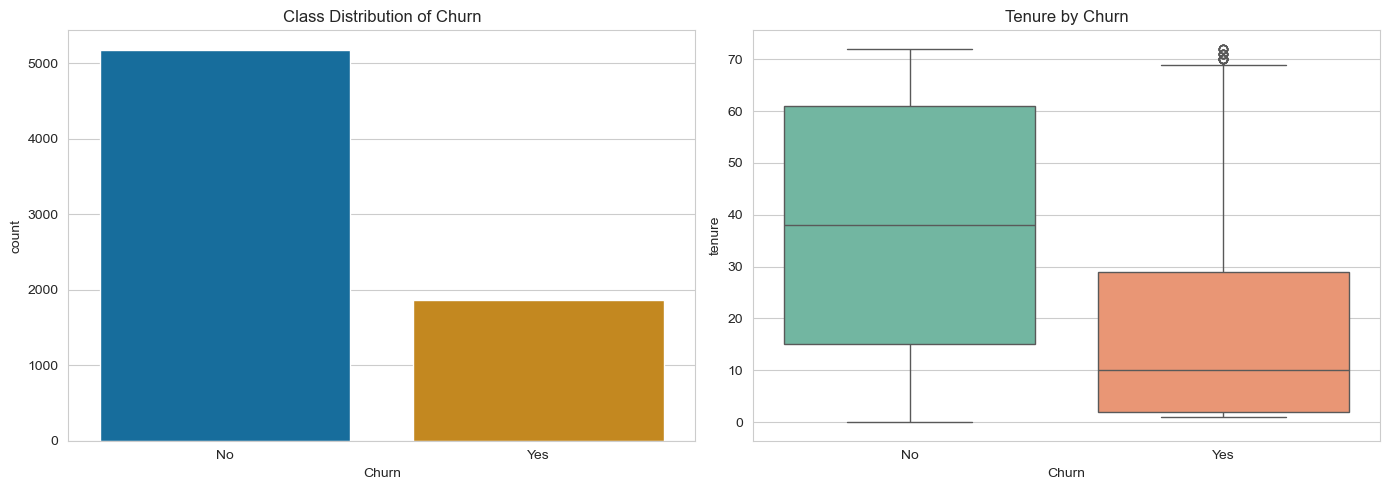

In [5]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Churn', hue='Churn', ax=axes[0], legend=False)
axes[0].set_title('Class Distribution of Churn')
axes[0].set_xlabel('Churn')

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1], hue='Churn', palette='Set2')
axes[1].set_title('Tenure by Churn')

plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight', dpi=100)
plt.show()

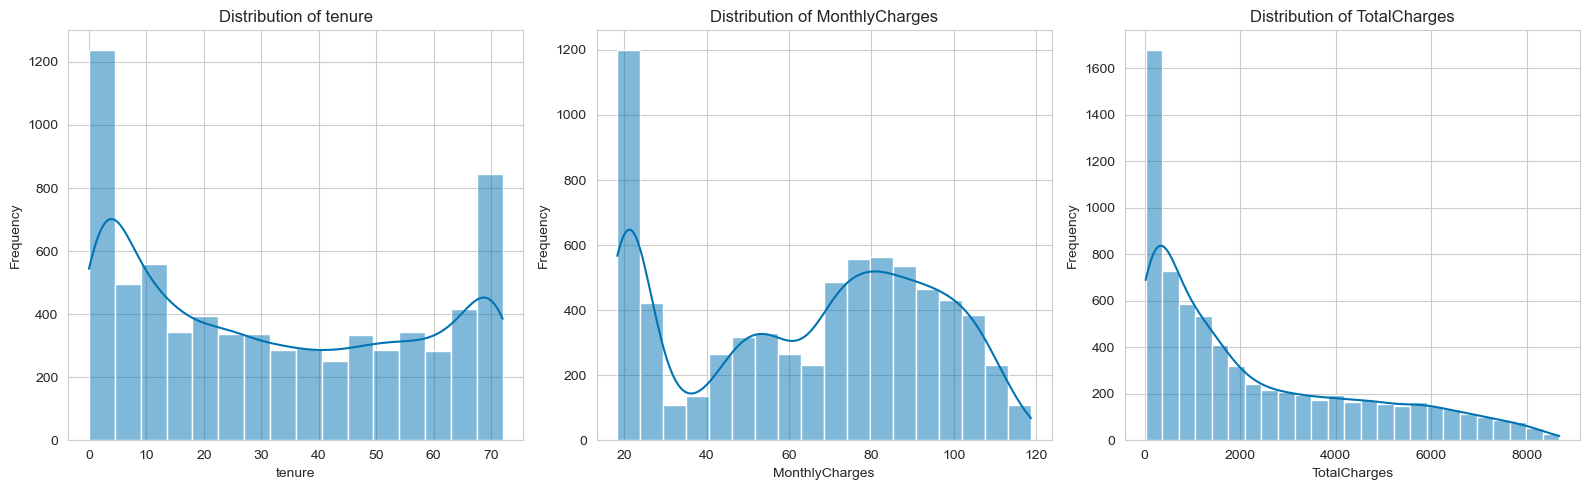

In [7]:
# Distribution plots for all numeric features
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('SeniorCitizen')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('feature_distribution_1.png', bbox_inches='tight', dpi=100)
plt.show()

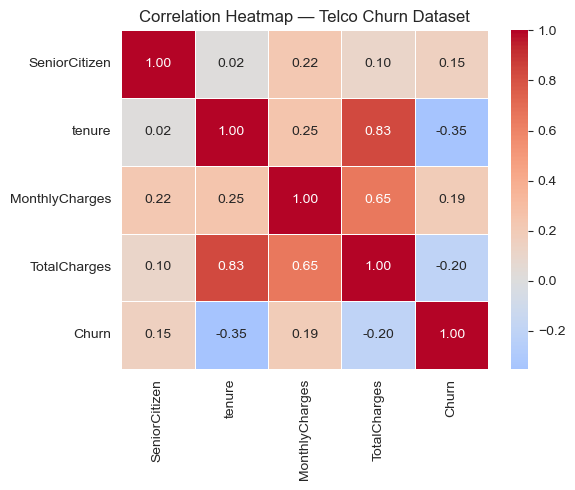

In [8]:
#Correlation heatmap
# Churn is text at this point by design (see A1) - mapped to a throwaway numeric
# series purely so it can appear in this correlation matrix, exactly like a numeric
# target normally would. This mapping is NOT saved back into df.
plt.figure(figsize=(6,5))
numeric_df = df.select_dtypes(include=[np.number]).copy()
numeric_df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap — Telco Churn Dataset')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=100)
plt.show()

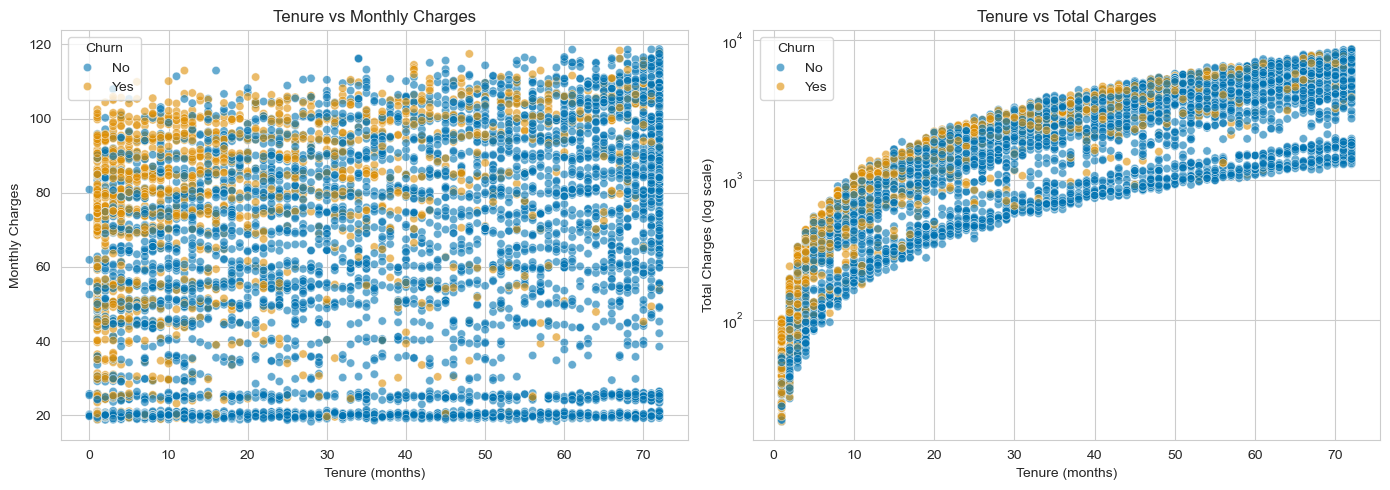

In [9]:
# Scatter plots: feature relationships, coloured by target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', ax=axes[0], alpha=0.6)
axes[0].set_title('Tenure vs Monthly Charges')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Monthly Charges')

sns.scatterplot(data=df, x='tenure', y='TotalCharges', hue='Churn', ax=axes[1], alpha=0.6)
axes[1].set_title('Tenure vs Total Charges')
axes[1].set_yscale('log')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Total Charges (log scale)')

plt.tight_layout()
plt.savefig('scatter_relationships.png', bbox_inches='tight', dpi=100)
plt.show()

### A3. Insight commentary

**Observation:**

- **Target distribution**: Churn is imbalanced — 73.5% "No" vs 26.5% "Yes" — so accuracy alone would be a misleading metric; precision, recall, F1 and ROC-AUC matter more here.

- **Tenure by churn**: The boxplot shows churners have noticeably shorter tenure than non-churners — churn is concentrated in the early months of the customer relationship.

- **Feature distributions**: `TotalCharges` is heavily right-skewed (a long tail of long-tenure, high-spend customers), while `tenure` is fairly spread out with a spike near 0 (new customers) and another near 70+ (very loyal customers).

- **Correlation heatmap**: `tenure` and `TotalCharges` are very strongly positively correlated (as expected, since total charges accumulate over tenure), and both correlate negatively with `Churn` — longer-tenured, higher-total-spend customers churn less. `MonthlyCharges` correlates positively with `Churn`, suggesting price sensitivity plays a role. The strong `tenure`-`TotalCharges` correlation flags potential multicollinearity to keep in mind for linear models like Logistic Regression.

- **Tenure vs. Monthly/Total Charges (scatter)**: Churned customers cluster heavily at low tenure regardless of monthly charge level, while long-tenure customers rarely churn even at higher charges — reinforcing that tenure, not price alone, is the dominant separator visible here.


<h1 style="font-family: Arial, sans-serif; font-size: 30px; font-weight: 400;">
Section B — Preprocessing & Feature Engineering
</h1>

In [11]:
data1 = df.copy()

# --- Missing values: show how many, first ---
print("=== Missing values BEFORE handling ===")
display(data1.isnull().sum())

# --- Duplicates: show how many, first ---
n_dupes = data1.duplicated().sum()
print(f"\n=== Duplicate rows found: {n_dupes} ===")

# Now handle: remove duplicates
data1 = data1.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", data1.shape)

# Now handle: remove rows where target is missing
data1 = data1.dropna(subset=['Churn']).reset_index(drop=True)
print("Final shape after target cleaning:", data1.shape)

=== Missing values BEFORE handling ===


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


=== Duplicate rows found: 0 ===
Shape after removing duplicates: (7043, 21)
Final shape after target cleaning: (7043, 21)


In [12]:
#Split feature and target
X = data1.drop(columns=['Churn', 'customerID'])
y = data1['Churn'].map({'No': 0, 'Yes': 1})

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [14]:
print("=== Missing values in X_train BEFORE imputation ===")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("\n=== Missing values in X_test BEFORE imputation ===")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

=== Missing values in X_train BEFORE imputation ===
TotalCharges    8
dtype: int64

=== Missing values in X_test BEFORE imputation ===
TotalCharges    3
dtype: int64


In [16]:
#Handling missing values
#numeric
imputer = SimpleImputer(strategy='median')
num_cols = X_train.select_dtypes(include='number').columns

imputer = SimpleImputer(strategy='median')

X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])
#catogorical
cat_imputer = SimpleImputer(strategy='most_frequent')

cat_cols = X_train.select_dtypes(include='object').columns

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

In [14]:
print('=== Missing values in X_train AFTER imputation ===')
X_train.isnull().sum()

=== Missing values in X_train AFTER imputation ===


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [17]:
print('=== Missing values in X_test AFTER imputation ===')
X_test.isnull().sum()

=== Missing values in X_test AFTER imputation ===


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [19]:
#Outliers
Q1 = X_train.select_dtypes(include='number').quantile(0.25)
Q3 = X_train.select_dtypes(include='number').quantile(0.75)

IQR = Q3 - Q1

outliers = ((X_train.select_dtypes(include='number') < (Q1 - 1.5 * IQR)) |
            (X_train.select_dtypes(include='number') > (Q3 + 1.5 * IQR))).sum()

outliers

SeniorCitizen     920
tenure              0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [20]:
#Handling Outliers using IQR capping (winsorization)
num_cols = X_train.select_dtypes(include='number').columns

Q1 = X_train[num_cols].quantile(0.25)
Q3 = X_train[num_cols].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

X_train[num_cols] = X_train[num_cols].clip(lower, upper, axis=1)
X_test[num_cols] = X_test[num_cols].clip(lower, upper, axis=1)

In [23]:
#Encoding using One Hot
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

cat_cols = X_train.select_dtypes(include='object').columns

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

encoded_cols = encoder.get_feature_names_out(cat_cols)

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_cols,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_cols,
    index=X_test.index
)

# Remove original categorical columns
X_train = X_train.drop(columns=cat_cols)
X_test = X_test.drop(columns=cat_cols)

# Add encoded columns at once
X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)

In [26]:
X_train_columns = X_train.columns
X_test_columns = X_test.columns

In [27]:
#Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
X_train = pd.DataFrame(X_train, columns=X_train_columns)
X_test = pd.DataFrame(X_test, columns=X_test_columns)

In [29]:
#Feature Engineering
X_train['Charges_Per_Tenure'] = X_train['TotalCharges'] / (X_train['tenure'] + 1)
X_test['Charges_Per_Tenure'] = X_test['TotalCharges'] / (X_test['tenure'] + 1)

service_cols = [c for c in X_train.columns if c.startswith((
    'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
    'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes'
))]
X_train['NumServices'] = X_train[service_cols].sum(axis=1)
X_test['NumServices'] = X_test[service_cols].sum(axis=1)

<h1 style="font-family: Arial, sans-serif; font-size: 22px; font-weight: 400;">
JUSTIFICATION
</h1>


1. Charges_Per_Tenure
Charges_Per_Tenure was created to capture how much a customer pays on average per month of their relationship with the company, independent of raw tenure length. This may improve model performance because two customers with the same MonthlyCharges but very different tenures can have very different total-spend patterns.

 2. NumServices was created to capture how many optional add-on services (security, backup, device protection, tech support, streaming TV, streaming movies) a customer has subscribed to.
    This may improve model performance because customers more deeply invested in the company's ecosystem through multiple services tend to be stickier and less likely to churn.

<h1 style="font-family: Arial, sans-serif; font-size: 30px; font-weight: 400;">
Section D — Classification
</h1>


<h1 style="font-family: Arial, sans-serif; font-size: 20px; font-weight: 200;">
1:Logistic Regression
</h1>

In [32]:
# Create model
logreg = LogisticRegression(random_state=42, max_iter=1000)

# Train model
logreg.fit(X_train, y_train)

# Predict
y_pred_logreg = logreg.predict(X_test)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]

# Evaluation
acc_logreg = accuracy_score(y_test, y_pred_logreg)
prec_logreg = precision_score(y_test, y_pred_logreg)
rec_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_proba_logreg)

print("Logistic Regression")
print("Accuracy:", acc_logreg)
print("Precision:", prec_logreg)
print("Recall:", rec_logreg)
print("F1 Score:", f1_logreg)
print("ROC-AUC:", auc_logreg)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg))

Logistic Regression
Accuracy: 0.7955997161107168
Precision: 0.6327160493827161
Recall: 0.5481283422459893
F1 Score: 0.5873925501432665
ROC-AUC: 0.8410576351752823

Confusion Matrix:
 [[916 119]
 [169 205]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

